# Análise Estratégica de Churn - Telco Analytics

**Objetivo:** Identificar o perfil de cliente com maior risco de evasão (Churn) e o impacto financeiro dessa perda, propondo ações baseadas em dados para melhorar a retenção.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# Configuração visual do gráfico
sns.set(style="darkgrid")

# Carregando os dados
dados = pd.read_csv('queries_data_cleaning.csv')
dados['TotalCharges'] = pd.to_numeric(dados['TotalCharges'], errors='coerce').fillna(0)

## 1. O Tamanho do Problema (Macro)
Primeiro, precisamos entender qual é a taxa atual de evasão da empresa e quanto dinheiro isso representa no caixa.

Total de clientes na base: 7043
Clientes perdidos (Churn): 1869 (26.54%)
Impacto Financeiro (Receita Perdida): $2,862,926.90


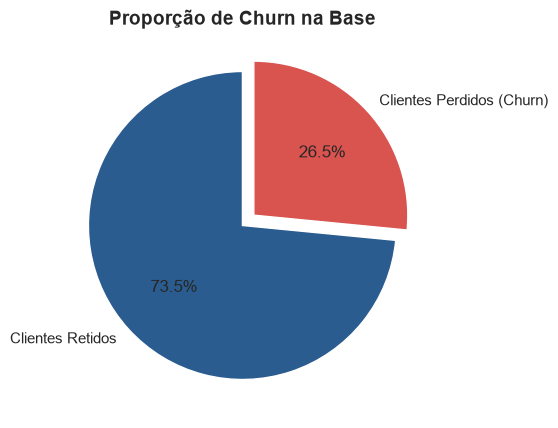

In [ ]:
total_clientes = len(dados)
filtro_churn = (dados['Churn'] == True)
total_churn = filtro_churn.sum()
taxa_churn = (filtro_churn / total_clientes) * 100

receita_perdida_total = dados[filtro_churn]['TotalCharges'].sum()

print(f"Total de clientes na base: {total_clientes}")
print(f"Clientes perdidos (Churn): {total_churn} ({(total_churn / total_clientes * 100):.2f}%)")
print(f"Impacto Financeiro (Receita Perdida): ${receita_perdida_total:,.2f}")

labels = ['Clientes Retidos', 'Clientes Perdidos (Churn)']
valores = [total_clientes - total_churn, total_churn]
cores = ['#2b5c8f', '#d9534f']

plt.figure(figsize=(5, 5))
plt.pie(valores, labels=labels, autopct = '%1.1f%%', startangle=90, colors = cores, explode = (0, 0.1))
plt.title('Proporção de Churn na Base', fontsize=  14, fontweight = 'bold')
plt.show()

## 2. A Raiz do Problema: Contratos e LTV
Sabendo que estamos perdendo 26% da base, precisamos descobrir "onde" eles estão. Vamos analisar o comportamento financeiro por tipo de contrato.

In [ ]:
visao_completa_contrato = dados.groupby('Contract').agg(
    Qtd_Clientes = ('Churn', 'count'),
    Taxa_Churn_Perc=('Churn', lambda x: (x == True).mean() * 100), 
    Permanencia_Media_Meses = ('tenure_months', 'mean'),    
    LTV_Medio_Cliente = ('TotalCharges', 'mean')           
).reset_index().sort_values(by='Taxa_Churn_Perc', ascending = False)

visao_completa_contrato['Taxa_Churn_Perc'] = visao_completa_contrato['Taxa_Churn_Perc'].map('{:.2f}%'.format)
visao_completa_contrato['Permanencia_Media_Meses'] = visao_completa_contrato['Permanencia_Media_Meses'].map('{:.1f} meses'.format)
visao_completa_contrato['LTV_Medio_Cliente'] = visao_completa_contrato['LTV_Medio_Cliente'].map('${:,.2f}'.format)

print(visao_completa_contrato.to_string(index = False))

# Insight: O contrato Mensal concentra a maioria das perdas.

      Contract  Qtd_Clientes Taxa_Churn_Perc Permanencia_Media_Meses LTV_Medio_Cliente
Month-to-month          3875          42.71%              18.0 meses         $1,369.25
      One year          1473          11.27%              42.0 meses         $3,032.62
      Two year          1695           2.83%              56.7 meses         $3,706.93


## 3. O Fator "Atrito": Cruzando Pagamento e Contrato
Já sabemos que o contrato Mensal é o epicentro do Churn. Mas por que eles cancelam tanto? Vamos cruzar o tipo de contrato com a forma de pagamento para buscar padrões comportamentais.

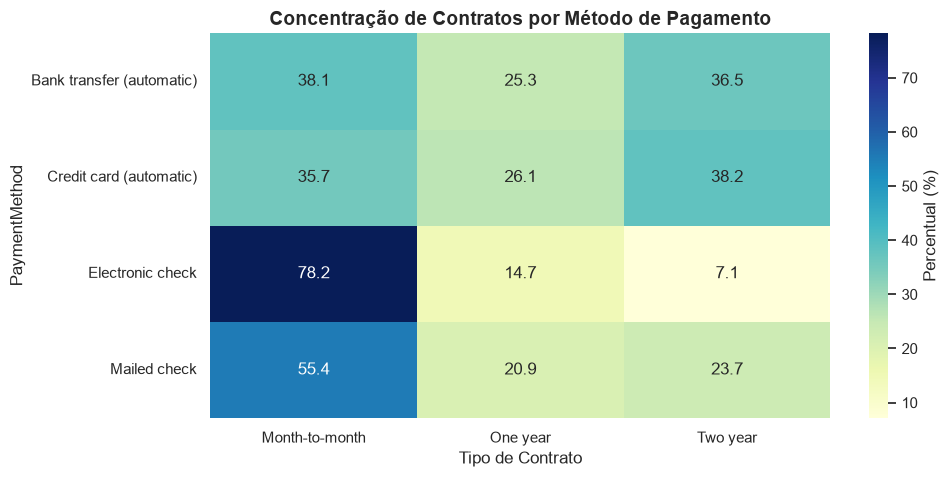

In [ ]:
cruzamento_pagemento_contrato = pd.crosstab(dados['PaymentMethod'], dados['Contract'], normalize = 'index') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(cruzamento_pagemento_contrato, annot = True, fmt = ".1f", cmap = "YlGnBu", cbar_kws = {'label': 'Percentual (%)'})
plt.title('Concentração de Contratos por Método de Pagamento', fontsize = 14, fontweight = 'bold')
plt.xlabel('Tipo de Contrato')
plt.show()

# Insight: Existe uma ligação perigosa entre o contrato Mensal e o Cheque Eletrônico.

## 4. Perfil de Risco: Solteiros e Sem Dependentes
Para focar a nossa campanha de retenção, isolamos o grupo demográfico que menos possui amarras financeiras e familiares: clientes sem parceiros e sem dependentes.

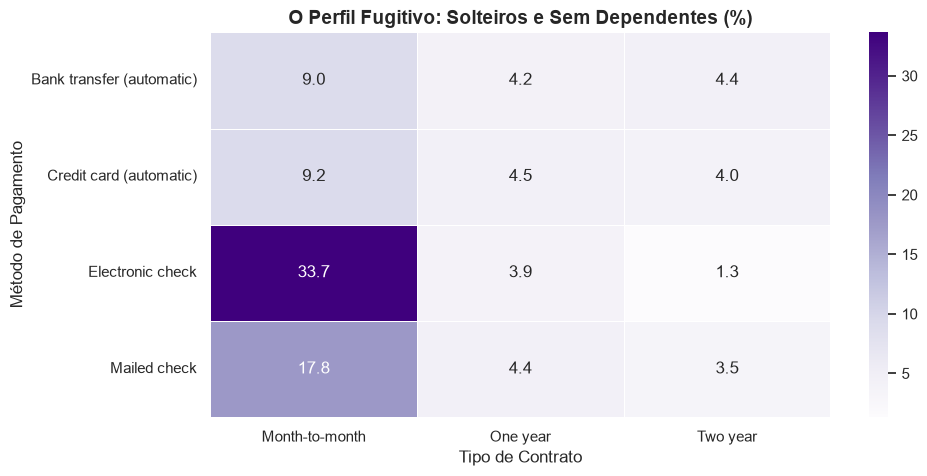

In [ ]:
dados_solteiros = dados[(dados['Partner'] == False) & (dados['Dependents'] == False)]

cruzamento_solteiros = pd.crosstab(dados_solteiros['PaymentMethod'], dados_solteiros['Contract'], normalize='all') * 100
plt.figure(figsize=(10, 5))
sns.heatmap(cruzamento_solteiros, annot=True, fmt=".1f", cmap="Purples", linewidths=.5
)
plt.title('O Perfil Fugitivo: Solteiros e Sem Dependentes (%)', fontsize=14, fontweight='bold')
plt.ylabel('Método de Pagamento')
plt.xlabel('Tipo de Contrato')
plt.show()

## 5. Tomada de Decisão (Plano de Ação)
Com base nos dados, substituir bruscamente o plano mensal pode prejudicar a aquisição de novos clientes. A estratégia recomendada é a **Fidelidade Invisível**:

1. **Incentivo ao Débito Automático:** Oferecer descontos agressivos na mensalidade para os clientes do plano Mensal (especialmente os solteiros) que migrarem do "Cheque Eletrônico" para o Cartão de Crédito Automático, reduzindo o atrito de pagamento mensal.
2. **Upsell no Ciclo Crítico:** Sabendo que a permanência média do plano mensal é de 18 meses, criar uma campanha de "upgrade para o plano anual" direcionada aos clientes que estão atingindo o 3º e o 6º mês de casa, oferecendo vantagens em velocidade ou streaming.